# Seminarski rad: *Poređenje linearnih metoda dimenzionalne redukcije u kontekstu klasifikacije*

In [2]:
import numpy as np
import pandas as pd

### Učitavanje i upoznavanje sa datasetom

In [3]:
# Ucitavanje dataseta
df = pd.read_csv('../data/fetal_health.csv')

In [4]:
# Osnovne dimenzije
print(f"Broj instanci (redova): {df.shape[0]}")
print(f"Broj atributa (kolona): {df.shape[1]}")

Broj instanci (redova): 2126
Broj atributa (kolona): 22


In [5]:
# Tipovi podataka
print("\n--- Tipovi podataka atributa ---")
print(df.dtypes)


--- Tipovi podataka atributa ---
baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                 

In [6]:
# Prvih 5 redova
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [7]:
# Osnovna statistika
print("\n--- Osnovne statističke mjere ---")
df.describe().round(2)


--- Osnovne statističke mjere ---


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.00,2126.00,2126.00,2126.00,2126.00,2126.0,2126.0,2126.00,2126.00,2126.00,...,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00
mean,133.30,0.00,0.01,0.00,0.00,0.0,0.0,46.99,1.33,9.85,...,93.58,164.03,4.07,0.32,137.45,134.61,138.09,18.81,0.32,1.30
std,9.84,0.00,0.05,0.00,0.00,0.0,0.0,17.19,0.88,18.40,...,29.56,17.94,2.95,0.71,16.38,15.59,14.47,28.98,0.61,0.61
min,106.00,0.00,0.00,0.00,0.00,0.0,0.0,12.00,0.20,0.00,...,50.00,122.00,0.00,0.00,60.00,73.00,77.00,0.00,-1.00,1.00
25%,126.00,0.00,0.00,0.00,0.00,0.0,0.0,32.00,0.70,0.00,...,67.00,152.00,2.00,0.00,129.00,125.00,129.00,2.00,0.00,1.00
50%,133.00,0.00,0.00,0.00,0.00,0.0,0.0,49.00,1.20,0.00,...,93.00,162.00,3.00,0.00,139.00,136.00,139.00,7.00,0.00,1.00
75%,140.00,0.01,0.00,0.01,0.00,0.0,0.0,61.00,1.70,11.00,...,120.00,174.00,6.00,0.00,148.00,145.00,148.00,24.00,1.00,1.00
max,160.00,0.02,0.48,0.02,0.02,0.0,0.0,87.00,7.00,91.00,...,159.00,238.00,18.00,10.00,187.00,182.00,186.00,269.00,1.00,3.00


In [8]:
# Distribucija (balansiranost) klasa
print("\n--- Balansiranost klasa ---")
counts = df['fetal_health'].value_counts().sort_index()
labels = {1.0: "Normal", 2.0: "Suspect", 3.0: "Pathological"}
for cls, count in counts.items():
    pct = count / len(df) * 100
    print(f"{labels[cls]} ({int(cls)}): {count} instanci ({pct:.1f}%)")


--- Balansiranost klasa ---
Normal (1): 1655 instanci (77.8%)
Suspect (2): 295 instanci (13.9%)
Pathological (3): 176 instanci (8.3%)


### Priprema podataka

In [9]:
# Provjera nedostajucih vrijednosti
print(df.isnull().sum())
print(f"\nUkupno nedostajućih vrijednosti: {df.isnull().sum().sum()}")

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

In [10]:
# Provjera duplikata
print(f"Broj duplikata: {df.duplicated().sum()}")

Broj duplikata: 13


In [11]:
# Uklanjanje duplikata
df = df.drop_duplicates()
df = df.reset_index(drop=True)

print(f"Oblik dataseta nakon uklanjanja duplikata: {df.shape}")

Oblik dataseta nakon uklanjanja duplikata: (2113, 22)


In [12]:
# Odvajanje featura i targeta
X = df.drop(columns=['fetal_health']).values
y = df['fetal_health'].values

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

Features (X): (2113, 21)
Target (y): (2113,)


In [13]:
feature_names = df.drop(columns=['fetal_health']).columns.tolist()
print("Atributi koje analiziramo:")
print(feature_names)
print(f"\nBroj atributa za analizu: {len(feature_names)}")
print(f"Jedinstvene klase: {np.unique(y)}")

Atributi koje analiziramo:
['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability', 'histogram_width', 'histogram_min', 'histogram_max', 'histogram_number_of_peaks', 'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean', 'histogram_median', 'histogram_variance', 'histogram_tendency']

Broj atributa za analizu: 21
Jedinstvene klase: [1. 2. 3.]


In [14]:
# Standardizacija
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
print("--- Prije standardizacije ---")
print(f" Mean: {X.mean():.2f}")
print(f" Std:  {X.std():.2f}")

print("\n--- Nakon standardizacije ---")
print(f" Mean: {X_scaled.mean():.2f}")
print(f" Std:  {X_scaled.std():.2f}")

--- Prije standardizacije ---
 Mean: 45.79
 Std:  61.05

--- Nakon standardizacije ---
 Mean: 0.00
 Std:  1.00


### Vizualizacija osnovnih karakteristika

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Raspodjela klasa

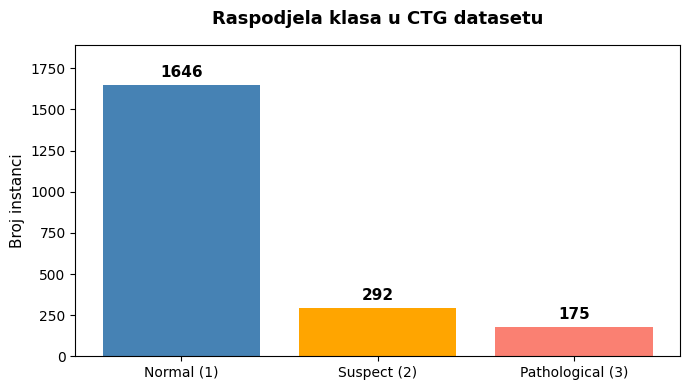

In [35]:
plt.figure(figsize=(7, 4))

labels = ['Normal (1)', 'Suspect (2)', 'Pathological (3)']
counts = [np.sum(y == 1.), np.sum(y == 2.), np.sum(y == 3.)]
colors = ['steelblue', 'orange', 'salmon']

bars = plt.bar(labels, counts, color = colors)

# procentualni pomak teksta iznad bar-a
max_count = max(counts)
offset = max_count * 0.02

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset, str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

# povecanje granice y-ose
plt.ylim(0, max_count * 1.15)

plt.title("Raspodjela klasa u CTG datasetu", fontsize=13, pad=15, fontweight='bold')
plt.ylabel("Broj instanci", fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150)
plt.show()

#### 2. Korelaciona matrica 

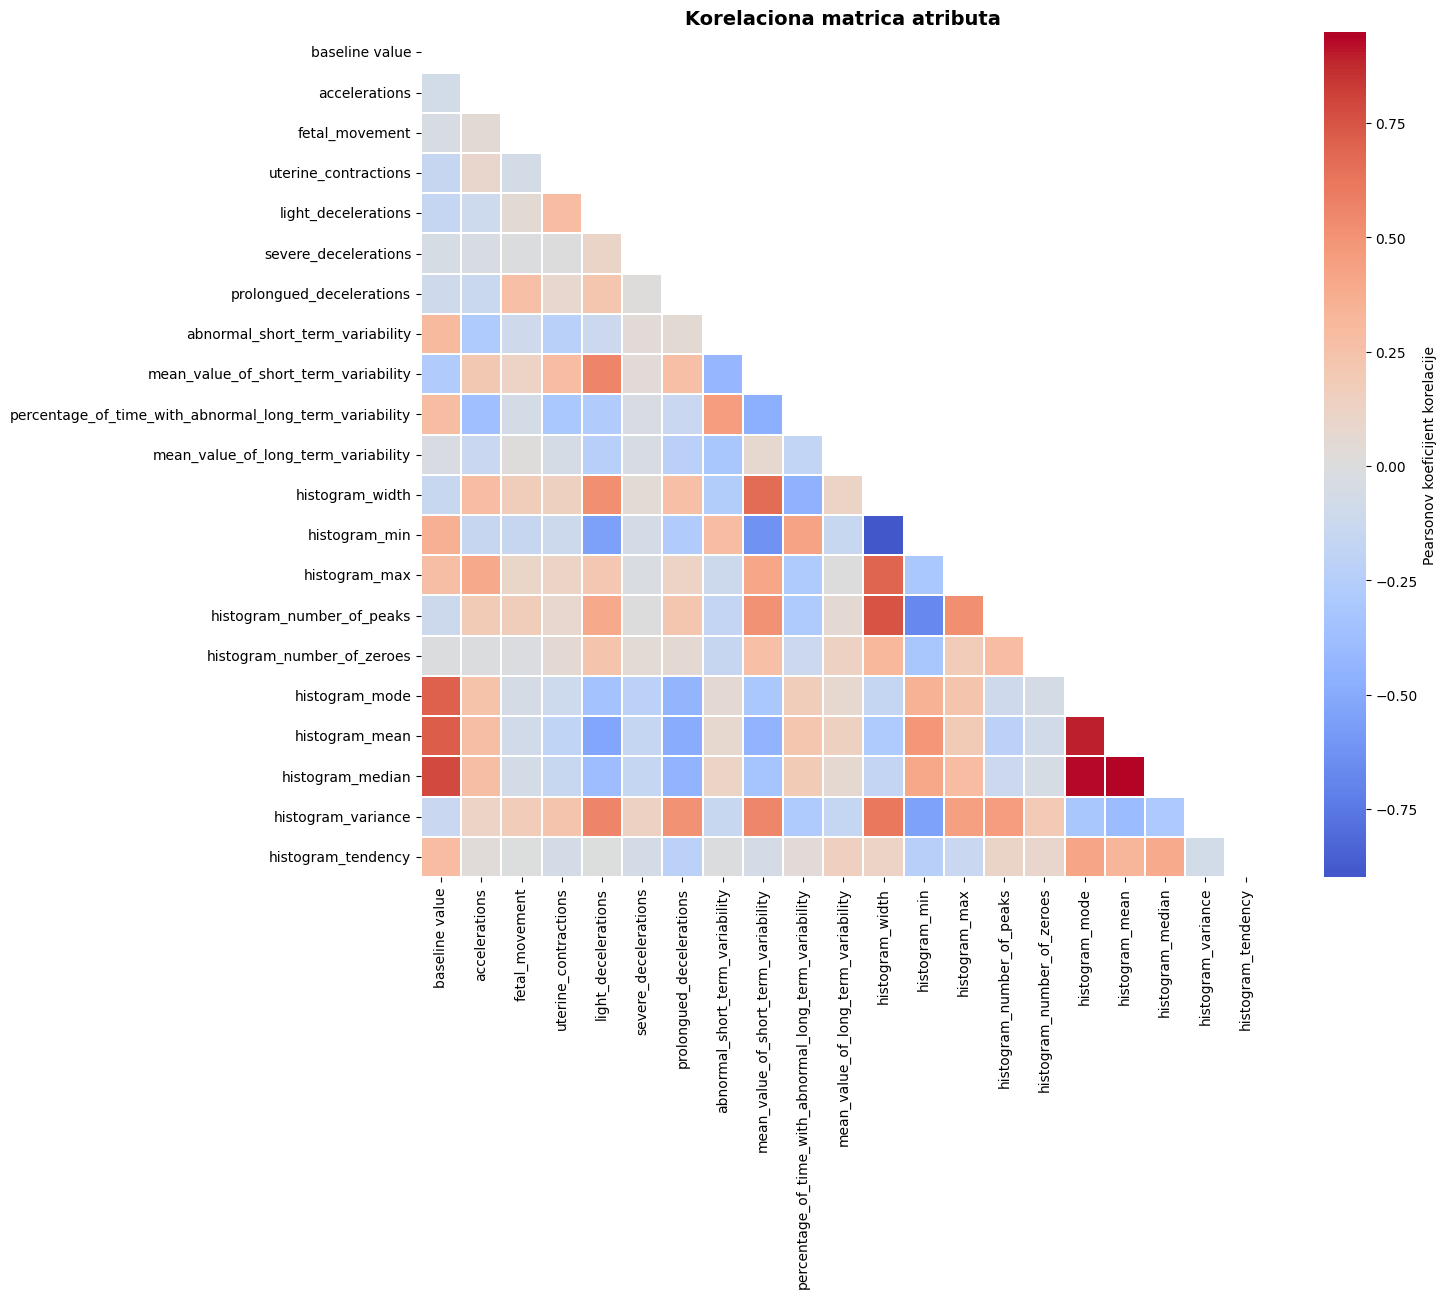

In [36]:
corr_matrix = pd.DataFrame(X, columns=feature_names).corr()
plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, square=True,
            cbar_kws={'label': 'Pearsonov koeficijent korelacije'})
plt.title('Korelaciona matrica atributa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_matrix.png', dpi=150)
plt.show()


In [38]:
print("--- Parovi atributa s |korelacijom| > 0.80 ---")
high_corr = []
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.80:
            high_corr.append((feature_names[i], feature_names[j], round(val, 3)))

if high_corr:
    for a, b, v in high_corr:
        print(f"  {a}  i  {b}  :  r = {v}")
else:
    print("Nema visoko korelisanih parova.")

--- Parovi atributa s |korelacijom| > 0.80 ---
  histogram_width  i  histogram_min  :  r = -0.899
  histogram_mode  i  histogram_mean  :  r = 0.893
  histogram_mode  i  histogram_median  :  r = 0.933
  histogram_mean  i  histogram_median  :  r = 0.948


### Primjena metoda linearne dimenzionalne redukcije